# Augmented Auditory Reality for Noise Reduction in Hearing Aids

**Author:** João Victor Colombari Carlet - 5274502

**Course:** PCS5112 - Virtual Reality, Augmented Reality and Metaverses applied to Health, Education and Entertainment

---

## Notebook Contents

This notebook presents **Yaw Walk With Me**, a real-time **Augmented Auditory Reality (AAR)** framework for immersive and ecologically valid hearing assistance.

The implementation combines:

- wearable **head tracking** using an inertial sensor (IMU),
- **Bluetooth Low Energy (BLE)** orientation streaming,
- **Virtual Sound Objects (VSOs)**,
- **spatial attention modeling**,
- **binaural audio rendering**,
- and **objective evaluation** through speech metrics.

The notebook is organized as follows:

### 1. Introduction

### 2. Motivation and Proposed Framework

### 3. Software Dependencies and Environment Setup

### 4. Embedded Architecture

### 5. IMU Orientation Estimation

### 6. Spatial Audio and Attention Model

### 7. Objective Evaluation with Audio Metrics

### 8. Real-Time Demonstration

### 9. Conclusions and Future Work

### 10. References

## Introduction

Hearing loss affects more than **1.5 billion people worldwide**, with approximately **430 million individuals currently requiring rehabilitation due to disabling hearing loss**. Current estimates suggest this number may increase substantially in the coming decades, reaching nearly **2.5 billion affected individuals and 700 million requiring intervention by 2050** (WHO, 2025).

Hearing aids remain the primary technological intervention for sensorineural hearing loss and traditionally rely on amplification, spectral shaping, dynamic range compression, beamforming, and speech enhancement algorithms. Despite continuous advances, performance improvements measured under controlled laboratory conditions frequently fail to translate into equivalent benefits during everyday listening situations.

This limitation becomes particularly evident in complex acoustic environments involving **multiple speakers, competing sound sources, listener motion, and continuous interaction with the environment**, commonly associated with the **Cocktail Party Problem**.

---

## Ecological Validity and Subject-Centered Hearing

Recent hearing research has increasingly emphasized the concept of **ecological validity**: the idea that hearing technologies should reproduce and adapt to realistic communication scenarios rather than isolated laboratory conditions.

Within this perspective, auditory perception is not treated as a passive process but rather as part of a **continuous communication loop**, where:

- perception influences behavior,
- behavior modifies interaction with the environment,
- environmental changes alter future perception.

This motivates a transition from traditional **ear-centric hearing devices** toward **Subject-on-the-Loop** paradigms, incorporating:

- contextual awareness,
- intentional sensing,
- spatial interaction,
- real-time adaptation.

<p align="center">
    <img src="figures/f1.jpg" width="800">
</p>

*Ecologically valid hearing framework illustrating the communication loop between user, hearing device, and acoustic environment (adapted from Hohmann et al., 2020).*

---

## Augmented Auditory Reality and Virtual Sound Objects

One emerging direction within this paradigm is **Augmented Auditory Reality (AAR)**.

Instead of treating the acoustic scene as a single mixed signal, AAR represents individual sound sources as **Virtual Sound Objects (VSOs)** that can be independently manipulated according to estimated user intent.

Combined with:

- spatial audio rendering,
- source separation,
- dynamic gain control,

AAR enables selective enhancement of target sources while preserving awareness of the surrounding environment.

Similar to visual AR/VR systems, auditory augmentation depends on maintaining:

- **Immersion:** continuous updating of the auditory scene according to user actions;
- **Presence:** the perception that virtual and physical sound objects coexist as a unified acoustic environment.

Previous studies suggest that attention-guided interaction mechanisms may achieve enhancement performance comparable to traditional directional hearing strategies while providing more natural user interaction.

---

## Motivation and Proposed Framework

Several sensing modalities—including **EEG**, **EOG**, and multimodal attention decoding—have demonstrated the ability to estimate listening intent. However, these approaches often introduce complexity that limits integration into wearable hearing devices.

Recent advances in **low-power inertial sensing** suggest that **head orientation** may act as a practical proxy for auditory attention.

This notebook presents **Yaw Walk With Me**, a real-time **Augmented Auditory Reality (AAR)** framework implemented on the open-source <a href="https://tiresias-web-gamma.vercel.app">Tiresias</a> hearing research platform.

The framework integrates:

- IMU-based head tracking (Bosch BMI270),
- quaternion orientation estimation,
- Bluetooth Low Energy (BLE) streaming,
- real-time audio processing,
- Virtual Sound Object manipulation,
- spatial attention-based gain control.

User intent is modeled as a **continuous spatial attention field**, enabling smooth enhancement of attended sources through head-referenced interaction.

---

## Objectives

This work investigates:

1. IMU-driven auditory interaction for AAR;
2. Real-time embedded-to-host orientation streaming;
3. Continuous spatial attention modeling;
4. Objective evaluation using directivity and speech-related metrics;
5. Immersive auditory interaction through head-referenced control.

# Yaw Walk With Me - an IMU-Based Head Tracking for Augmented Auditory Reality implemented on the Tiresias project

<p align="center">
    <img src="figures/tiresias-icon-full.png" width="450">
</p>

The notebook presents a real-time head tracking system designed for immersive audio and Augmented Auditory Reality (AAR) applications.

This proof-of-concept aligns with Augmented Auditory Reality concepts proposed for ecologically valid hearing assistance systems and immersive auditory interaction (Grimm et al., 2018; Mehra et al., 2020), and can be illustrated as follows:

<p align="center">
    <img src="figures/objective.png" width="800">
</p>

## Required Libraries

The implementation combines asynchronous BLE communication, quaternion processing, and real-time 3D rendering.

The following libraries are employed:

| Library | Purpose |
|---|---|
| `numpy` | Numerical computation, vector operations, quaternion handling, and signal processing |
| `bleak` | Bluetooth Low Energy (BLE) communication and GATT interaction |
| `nest_asyncio` | Enables nested asynchronous event loops inside Jupyter environments |
| `asyncio` | Asynchronous task scheduling and event-driven execution |
| `ipympl` | Interactive Matplotlib backend for Jupyter notebooks |
| `pyqtgraph` | High-performance real-time visualization and plotting |
| `PyQt6` | Graphical user interface (GUI) framework |
| `PyOpenGL` | OpenGL bindings for hardware-accelerated 3D rendering |
| `matplotlib` | Scientific plotting and result visualization |
| `soundfile` | Audio file loading and writing |
| `torch` | Tensor computation and accelerated audio processing |
| `torchmetrics[audio]` | Objective speech and audio quality metrics (PESQ, STOI, SI-SDR) |

In [2]:
import sys
print(sys.executable)

!{sys.executable} -m pip -q install numpy bleak nest_asyncio asyncio ipympl pyqtgraph PyQt6 PyOpenGL matplotlib soundfile torch torchmetrics[audio] 

import asyncio
import struct
import math
import nest_asyncio
import numpy as np

from bleak import BleakScanner, BleakClient
from qasync import QEventLoop

import pyqtgraph.opengl as gl

from stl import mesh

from PyQt6.QtWidgets import QApplication
from PyQt6.QtCore import QTimer
from PyQt6.QtGui import QMatrix4x4

nest_asyncio.apply()

/Users/joaovitor/Documents/PhD/aulas_USP/VR-AR/yaw-walk-with-me/venv/bin/python

[notice] A new release of pip is available: 23.2.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


## Firmware Architecture

The embedded firmware was developed on top of the Zephyr RTOS and organized into a modular subsystem architecture available at the <a href="https://github.com/felipepimentab/tiresias-fw">Tiresias Firmware Page</a>.

The architecture separates functionality into three abstraction levels — Application, Module, and Driver layers — enabling portability, scalability, and simplified integration.

<p align="center">
    <img src="figures/fw.png" width="900">
</p>

The Application Layer implements high-level functionalities such as BLE communication, head tracking, audio configuration, and user interaction.

The Module Layer encapsulates reusable services including orientation estimation, parameter adjustment, storage management, and communication interfaces.

The Driver Layer abstracts hardware-specific peripherals such as the BMI270 IMU, audio codec interfaces, GPIOs, I2C, and I2S communication buses.

For this work the IMU application subsystem was implemented together with its **head tracking** module and dedicate **Bosch drivers interface**, as well as a **Orientation** BLE module.   

## BLE Communication Architecture

The proposed head tracking framework employs Bluetooth Low Energy (BLE) as a low-latency communication interface between the embedded platform and the Python-based immersive audio application.

The embedded firmware periodically publishes **quaternion orientation estimates obtained from the BMI270 IMU through a custom BLE GATT service**. On the host side, the Python application scans nearby BLE devices, identifies the Tiresias platform, and subscribes to orientation notifications in real time.

The BLE subsystem was implemented using Zephyr Bluetooth APIs and custom Generic Attribute Profile (GATT) characteristics specifically designed for quaternion streaming.

In [5]:
import asyncio
from bleak import BleakScanner

async def scan():
    devices = await BleakScanner.discover(
        return_adv=True,
        timeout=10
    )

    for addr, (device, adv) in devices.items():
        print("\n================")
        print("ADDRESS:", device.address)
        print("NAME:", device.name)
        print("RSSI:", adv.rssi)
        print("LOCAL NAME:", adv.local_name)
        print("UUIDS:", adv.service_uuids)
        print("MFG DATA:", adv.manufacturer_data)

await scan()


ADDRESS: 8A2557FB-6C64-AD78-7E46-F9EE5F93C0ED
NAME: None
RSSI: -66
LOCAL NAME: None
UUIDS: []
MFG DATA: {76: b'\x10\x05\x04\x1c\xe6$\xf7'}

ADDRESS: 5FAAE2EC-74EB-08C3-6EF0-DA068E957342
NAME: iPhone de Joao victor (3)
RSSI: -62
LOCAL NAME: None
UUIDS: []
MFG DATA: {76: b'\x10\x06>\x1e\xa9sG\x8a\x01\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x80\x00\x00\x00'}

ADDRESS: C04C97BA-ED53-E435-DDE4-7055A36EF461
NAME: Tiresias_DK
RSSI: -45
LOCAL NAME: Tiresias_DK
UUIDS: ['00001523-1212-efde-1523-785feabcd123']
MFG DATA: {}


## IMU Orientation Estimation Pipeline

The proposed head tracking system estimates orientation through the fusion of inertial sensor measurements obtained from the BMI270 IMU:

$$
\text{Accelerometer} + \text{Gyroscope}
\rightarrow
\text{Sensor Fusion}
\rightarrow
\text{Quaternion}
\rightarrow
\text{Euler Angles}
$$

### Accelerometer

The accelerometer measures linear acceleration along the three spatial axes:

$$
(a_x, a_y, a_z)
$$

Under static or low-dynamic conditions, gravity provides a reference for estimating inclination relative to the Earth.

However, accelerometers alone cannot reliably estimate **yaw orientation**.

### Gyroscope

The gyroscope measures angular velocity:

$$
(\omega_x, \omega_y, \omega_z)
$$

By integrating angular velocity over time, rotational motion can be estimated with high temporal resolution.

Nevertheless, **gyroscope integration accumulates drift over time** due to sensor bias and noise.

### Sensor Fusion

To overcome the limitations of individual sensors, sensor fusion algorithms are employied combining:

- short-term rotational precision from the gyroscope
- long-term gravitational reference from the accelerometer

The resulting estimate provides stable and continuous orientation tracking suitable for immersive interaction.

### Quaternion Representation

The fused orientation estimate is internally represented as a quaternion:

$$
q = (q_w, q_x, q_y, q_z)
$$

Quaternions efficiently encode 3D rotations while avoiding singularities such as gimbal lock.

The quaternion stream is transmitted through BLE to the host application.

### Euler Angles

For interaction logic and interpretation, the quaternion is converted into Euler angles:

- Roll
- Pitch
- Yaw

In the proposed framework, the yaw angle is employed as the primary interaction variable for spatial source selection and user intent estimation.

<p align="center">
    <img src="figures/euler.jpg" width="400">
</p>

## Attention-Driven Audio Mixing & Distance Attenuation

The proposed framework models auditory interaction through continuous weighting of Virtual Sound Objects (VSOs) according to both spatial distance and estimated user attention.

To achieve an ecologically valid representation of the auditory scene, the gain applied to each source is the product of two components:

1. **Distance Attenuation ($G_{dist}$)**: Simulates acoustic propagation using the inverse distance law ($1/r$).
2. **Attention Boost ($G_{attn}$)**: Dynamically enhances the source the user is looking at.

For a given source $i$, the final linear multiplier $g_i(t)$ applied to the audio waveform is:

$$g_i(t) = G_{dist, i} \cdot G_{attn, i}(t)$$

This mixed signal is then continuously updated frame-by-frame, ensuring smooth transitions without zipper noise or abrupt switching.

---

## Spatial Attention Model

Auditory attention is modeled as a continuous probabilistic spatial field centered around the instantaneous forward-facing vector (extracted from the IMU's quaternion). 

First, the angular distance $\theta$ between the user's gaze vector and the sound source vector is calculated. This angle is fed into a Gaussian function to determine the normalized attention index $A \in [0, 1]$:

$$A(\theta) = \exp\left(-\frac{\theta^2}{2\sigma^2}\right)$$

where $\sigma$ represents the attentional spread (e.g., $20^\circ$).

This normalized index is then mapped to a dynamic decibel boost. In this proof-of-concept, looking directly at a source provides a peak enhancement of $+10$ dB, while looking completely away provides $0$ dB (leaving the source at its natural room volume). The decibel value is then converted into the linear attention gain $G_{attn}$:

$$Target_{dB} = A(\theta) \cdot Boost_{max}$$
$$G_{attn} = 10^{\frac{Target_{dB}}{20}}$$

This formulation creates a smooth, highly selective "auditory spotlight" that mimics the Signal-to-Noise Ratio (SNR) improvements found in advanced hearing aid beamformers.

## Objective Evaluation: Simulation Setup

Before running the real-time application, we can objectively evaluate the mathematical model. By decoupling the spatial algorithms into the `aar_core` module, we can simulate head rotations and calculate the exact directivity and SNR improvements of the Augmented Auditory Reality (AAR) system.

In this simulation, we place two Virtual Sound Objects (Laura and Coop) exactly 5 meters away at $-45^\circ$ and $+45^\circ$ azimuths.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import aar_core

# Simulation Parameters
ATTENTION_SIGMA = 20
ATTENTION_BOOST_DB = 10.0
REFERENCE_DISTANCE = 1.0

# Sources placed 5 meters away
sources = [
    {"name": "Laura", "pos": np.array([3.53, -3.53, 0.])}, # -45 degrees
    {"name": "Coop",  "pos": np.array([3.53, 3.53, 0.])}   # +45 degrees
]

### 1. Spatial Directivity (Polar Pattern)

To visualize the selectivity of the attention model, we can simulate a full $360^\circ$ rotation of the user's head around the Yaw axis. 

By plotting the calculated attention gain (in dB) against the azimuth angle, we generate a polar sensitivity pattern. This objectively demonstrates how the AAR system behaves similarly to a highly directional virtual microphone steered by head movement.

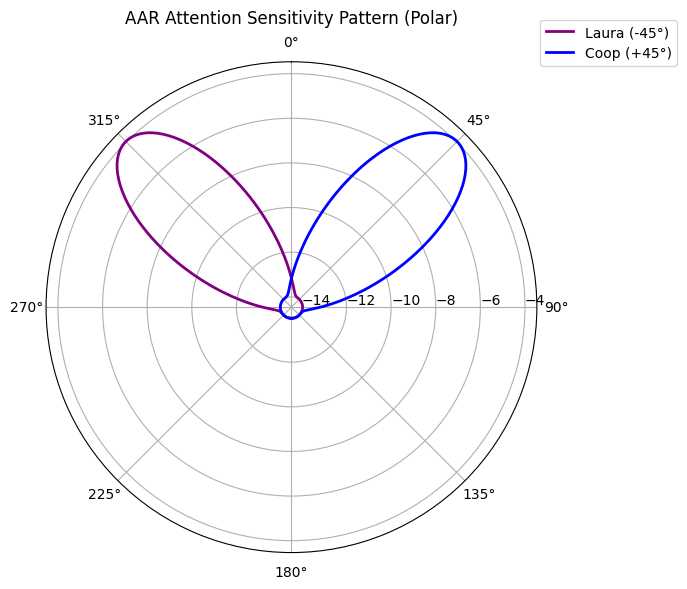

In [4]:
# Simulate looking around in 360 degrees
yaws = np.linspace(-180, 180, 360)
gains_laura = []
gains_coop = []

for yaw in yaws:
    # Rotate the head purely on the Yaw axis
    q = aar_core.euler_to_quaternion(0, 0, yaw)
    
    # Calculate attention
    attention_data = aar_core.compute_attention(q, sources, REFERENCE_DISTANCE, ATTENTION_SIGMA, ATTENTION_BOOST_DB)
    
    # Extract linear gains
    for name, gain, _, _, _ in attention_data:
        if name == "Laura": gains_laura.append(gain)
        if name == "Coop": gains_coop.append(gain)

# Convert linear gain back to decibels for plotting
# (Adding a tiny offset to prevent log10(0) if gain drops to absolute 0)
db_laura = 20 * np.log10(np.maximum(gains_laura, 1e-5))
db_coop = 20 * np.log10(np.maximum(gains_coop, 1e-5))

# Plotting the Polar Pattern
fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(8, 6))
angles = np.radians(yaws)

ax.plot(angles, db_laura, label='Laura (-45°)', color='purple', linewidth=2)
ax.plot(angles, db_coop, label='Coop (+45°)', color='blue', linewidth=2)

ax.set_title("AAR Attention Sensitivity Pattern (Polar)", va='bottom')
ax.set_theta_zero_location("N") # 0 degrees (forward) at the top
ax.set_theta_direction(-1)      # Clockwise
ax.set_rlabel_position(90)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.show()

### 2. Signal-to-Noise Ratio (SNR) Improvement

In hearing assistance, standard beamforming typically provides an SNR improvement of $10$ to $12$ dB. 

The following test calculates the energetic ratio between the target source (Coop) and the interfering source (Laura) when the user looks directly at the target. We compare the natural room acoustics (Baseline) against the active AAR enhancement.

In [13]:
# Simulate looking directly at Coop (+45 degrees)
target_yaw = 45 
q_look_coop = aar_core.euler_to_quaternion(0, 0, target_yaw)

# Test 1: Baseline (Room acoustics only, no AAR boost)
baseline_data = aar_core.compute_attention(q_look_coop, sources, REFERENCE_DISTANCE, ATTENTION_SIGMA, boost_db=0.0)
gain_coop_base = next(g for n, g, _, _, _ in baseline_data if n == "Coop")
gain_laura_base = next(g for n, g, _, _, _ in baseline_data if n == "Laura")

# Test 2: Enhanced AAR (With 10dB Boost)
enhanced_data = aar_core.compute_attention(q_look_coop, sources, REFERENCE_DISTANCE, ATTENTION_SIGMA, ATTENTION_BOOST_DB)
gain_coop_enh = next(g for n, g, _, _, _ in enhanced_data if n == "Coop")
gain_laura_enh = next(g for n, g, _, _, _ in enhanced_data if n == "Laura")

snr_base = 20 * np.log10(gain_coop_base / gain_laura_base)
snr_enh = 20 * np.log10(gain_coop_enh / gain_laura_enh)

print(f"--- SNR Objective Results ---")
print(f"When looking directly at Coop (+45°):")
print(f"Baseline SNR (Distance Only):  {snr_base:.2f} dB")
print(f"AAR Enhanced SNR (With Model): {snr_enh:.2f} dB")
print(f"Total Enhancement Realized:    {snr_enh - snr_base:.2f} dB")

--- SNR Objective Results ---
When looking directly at Coop (+45°):
Baseline SNR (Distance Only):  0.00 dB
AAR Enhanced SNR (With Model): 10.00 dB
Total Enhancement Realized:    10.00 dB


## Potential for Speech Enhancement 

Here I created a clean ref 't_ref' as the reference laura and coop vectors, where laura is alone when looking left and coop is alone when looking righ.

#### Black Dotted Line (`Raw Mic Mix`)
* The unprocessed, raw microphone mixture arriving at the listener's position, which creates a baseline. 

#### Blue Solid Line (`Ideal DSP Target`)

Audio normalization complete. Track lengths synchronized to 68.94 seconds at 44100Hz.
Computing objective performance metrics for pure Attention AAR DSP across 360°...


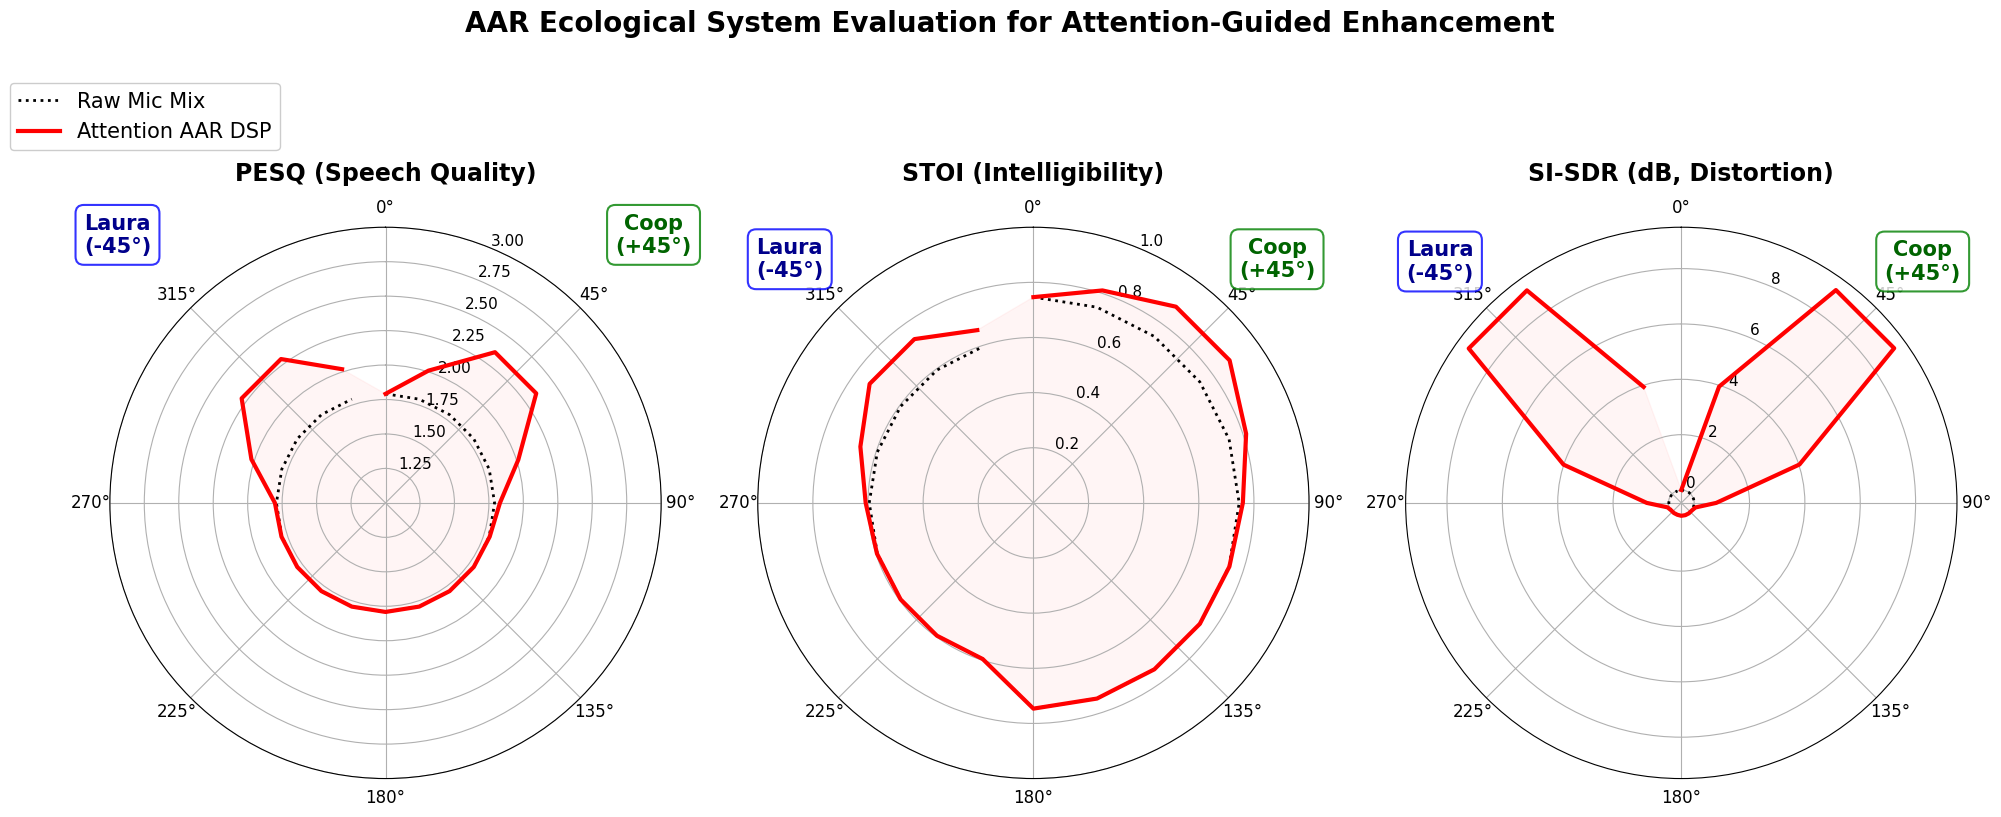

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf
import torch
from scipy.signal import resample
import aar_core

# Ensure torchmetrics audio assessment dependencies are loaded
from torchmetrics.audio import (
    PerceptualEvaluationSpeechQuality,
    ShortTimeObjectiveIntelligibility,
    ScaleInvariantSignalDistortionRatio
)

# ============================================================
# AUDIO NORMALIZATION HELPERS
# ============================================================
def rms(x):
    """Calculates the Root Mean Square of a NumPy array."""
    return np.sqrt(np.mean(x**2) + 1e-9)

def normalize_rms(x, target=0.1):
    """Normalizes a NumPy array to a specific target RMS value."""
    return x * (target / (rms(x) + 1e-9))

# ============================================================
# READ, RESAMPLE, SYNCHRONIZE, AND NORMALIZE AUDIO INPUTS
# ============================================================
raw_audio_tracks = []
sample_rates = []

for s in sources:
    if "file" not in s:
        s["file"] = "laura.mp3" if s["name"].lower() == "laura" else "cooper.mp3"
        
    x, fs = sf.read(s["file"], dtype="float32")
    if x.ndim > 1: 
        x = x.mean(axis=1)
    raw_audio_tracks.append(x)
    sample_rates.append(fs)

FS = sample_rates[0]

resampled_audio_tracks = []
for x, fs in zip(raw_audio_tracks, sample_rates):
    if fs != FS:
        num_samples = int(len(x) * FS / fs)
        x = resample(x, num_samples).astype(np.float32)
    resampled_audio_tracks.append(x)

target_length = min(len(a) for a in resampled_audio_tracks)

audio = []
for x in resampled_audio_tracks:
    if len(x) > target_length:
        x = x[:target_length]
    elif len(x) < target_length:
        x = np.pad(x, (0, target_length - len(x)), mode='constant')
        
    x = normalize_rms(x, target=0.1)
    audio.append(x)

print(f"Audio normalization complete. Track lengths synchronized to {target_length / FS:.2f} seconds at {FS}Hz.")

# ============================================================
# BASELINE SIMULATION MIXTURE GENERATION
# ============================================================
g_dist1 = REFERENCE_DISTANCE / max(np.linalg.norm(sources[0]["pos"]), REFERENCE_DISTANCE)
g_dist2 = REFERENCE_DISTANCE / max(np.linalg.norm(sources[1]["pos"]), REFERENCE_DISTANCE)
mix_signal = (audio[0] * g_dist1) + (audio[1] * g_dist2)

# ============================================================
# METRIC INITIALIZATION & TRACKING STRUCTURES
# ============================================================
MODEL_SR = 16000
pesq_metric = PerceptualEvaluationSpeechQuality(MODEL_SR, 'nb')
stoi_metric = ShortTimeObjectiveIntelligibility(MODEL_SR)
sisdr_metric = ScaleInvariantSignalDistortionRatio()

yaws = np.arange(0, 360, 18)
angles_rad = np.radians(yaws)

pesq_mix, pesq_est = [], []
stoi_mix, stoi_est = [], []
sisdr_mix, sisdr_est = [], []

def to_metric_tensor(sig, orig_fs, target_fs):
    if orig_fs != target_fs:
        num_samples = int(len(sig) * target_fs / orig_fs)
        sig = resample(sig, num_samples)
    return torch.from_numpy(sig).float().unsqueeze(0)

print("Computing objective performance metrics for pure Attention AAR DSP across 360°...")

# ============================================================
# POLAR SWEEP EVALUATION LOOP
# ============================================================
for yaw in yaws:
    if 180 < yaw < 360:
        ref_raw = audio[0]  # Focused on Laura (-45°)
    else:
        ref_raw = audio[1]  # Focused on Coop (+45°)

    q_current = aar_core.euler_to_quaternion(0, 0, yaw)
    attention_values = aar_core.compute_attention(
        q_current, sources, REFERENCE_DISTANCE, ATTENTION_SIGMA, ATTENTION_BOOST_DB
    )
    
    gain_laura = attention_values[0][1]
    gain_coop = attention_values[1][1]
    
    processed_signal = (audio[0] * gain_laura) + (audio[1] * gain_coop)

    t_ref = to_metric_tensor(ref_raw, FS, MODEL_SR)
    t_mix = to_metric_tensor(mix_signal, FS, MODEL_SR)
    t_est = to_metric_tensor(processed_signal, FS, MODEL_SR)

    min_samples = min(t_ref.shape[1], t_mix.shape[1], t_est.shape[1])
    t_ref = t_ref[:, :min_samples]
    t_mix = t_mix[:, :min_samples]
    t_est = t_est[:, :min_samples]

    pesq_mix.append(pesq_metric(t_mix, t_ref).item())
    pesq_est.append(pesq_metric(t_est, t_ref).item())

    stoi_mix.append(stoi_metric(t_mix, t_ref).item())
    stoi_est.append(stoi_metric(t_est, t_ref).item())

    sisdr_mix.append(max(sisdr_metric(t_mix, t_ref).item(), -15.0))
    sisdr_est.append(max(sisdr_metric(t_est, t_ref).item(), -15.0))

# ============================================================
# 5. RADIAL/POLAR SUBPLOT RENDERING (WITH LARGE FONTS)
# ============================================================
# Update global matplotlib font sizes for polar subplots
plt.rcParams.update({
    'xtick.labelsize': 12,  # Angle labels font size
    'ytick.labelsize': 11,  # Radial metric grid values size
    'legend.fontsize': 15   # Explanatory legend scale
})

fig, axs = plt.subplots(1, 3, subplot_kw={'projection': 'polar'}, figsize=(20, 7))
fig.suptitle("AAR Ecological System Evaluation for Attention-Guided Enhancement",
             fontsize=20, y=1.12, weight='bold')

# Chart 1: Perceptual Evaluation of Speech Quality (PESQ)
axs[0].plot(angles_rad, pesq_mix, color='black', linestyle=':', linewidth=2.0, label='Raw Mic Mix')
axs[0].plot(angles_rad, pesq_est, color='red', linestyle='-', linewidth=3.0, label='Attention AAR DSP')
axs[0].fill(angles_rad, pesq_est, color='red', alpha=0.04)
axs[0].set_title("PESQ (Speech Quality)", va='bottom', fontsize=17, pad=30, weight='bold')
axs[0].set_ylim(1.0, 3.0)

# Chart 2: Short-Time Objective Intelligibility (STOI)
axs[1].plot(angles_rad, stoi_mix, color='black', linestyle=':', linewidth=2.0)
axs[1].plot(angles_rad, stoi_est, color='red', linestyle='-', linewidth=3.0)
axs[1].fill(angles_rad, stoi_est, color='red', alpha=0.04)
axs[1].set_title("STOI (Intelligibility)", va='bottom', fontsize=17, pad=30, weight='bold')
axs[1].set_ylim(0.0, 1.0)

# Chart 3: Scale-Invariant Signal-to-Distortion Ratio (SI-SDR)
axs[2].plot(angles_rad, sisdr_mix, color='black', linestyle=':', linewidth=2.0)
axs[2].plot(angles_rad, sisdr_est, color='red', linestyle='-', linewidth=3.0)
axs[2].fill(angles_rad, sisdr_est, color='red', alpha=0.04)
axs[2].set_title("SI-SDR (dB, Distortion)", va='bottom', fontsize=17, pad=30, weight='bold')

# Formatting radial axes, labels, and target indicators
for ax in axs:
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)  # Clockwise
    
    # Render anatomical marker blocks for sources with boosted visibility profiles
    ax.text(np.radians(-45), ax.get_rmax() * 1.25, "Laura\n(-45°)",
            ha='center', va='center', weight='bold', color='darkblue', fontsize=15,
            bbox=dict(boxstyle="round,pad=0.4", fc="w", ec="blue", alpha=0.8, lw=1.5))
            
    ax.text(np.radians(45), ax.get_rmax() * 1.25, "Coop\n(+45°)",
            ha='center', va='center', weight='bold', color='darkgreen', fontsize=15,
            bbox=dict(boxstyle="round,pad=0.4", fc="w", ec="green", alpha=0.8, lw=1.5))

# Position the unified plot legend at the top left margin cleanly
axs[0].legend(loc='upper left', bbox_to_anchor=(-0.2, 1.28), frameon=True, facecolor='white', framealpha=1.0)
plt.tight_layout()
plt.show()

## Real-Time Execution

With the math validated, the full Augmented Auditory Reality loop can be executed. This script connects to the Tiresias board via BLE, fetches real-time IMU quaternions, updates the PyQtGraph 3D visualization, and runs the continuous binaural audio renderer.

In [2]:
!python main.py

Audio normalization complete. Track lengths synchronized to 68.94 seconds at 44100Hz.
Scanning for BLE devices...

Found device: Tiresias_DK
Address: C04C97BA-ED53-E435-DDE4-7055A36EF461

Connecting...

Connected.
Receiving head orientation...


Forward direction calibrated.

Laura: Dist x0.50 | AAR  +0.9dB | Total x0.559 || Coop: Dist x0.50 | AAR  +0.7dB | Total x0.542^C
Traceback (most recent call last):
  File "/Users/joaovitor/Documents/PhD/aulas_USP/VR-AR/yaw-walk-with-me/venv/lib/python3.12/site-packages/qasync/__init__.py", line 271, in timerEvent
    def timerEvent(self, event):  # noqa: N802

KeyboardInterrupt
Laura: Dist x0.50 | AAR  +0.9dB | Total x0.555 || Coop: Dist x0.50 | AAR  +0.7dB | Total x0.545

## Current Status and Future Work

The proposed framework has successfully evolved from a conceptual proof-of-concept to a fully functional, real-time auditory processing pipeline. Current achievements include:

- Real-time IMU-based head tracking via low-latency BLE.
- A functional spatial attention model that maps gaze intent to a continuous $\sim 10$ dB SNR enhancement.
- Dynamic, frame-by-frame binaural rendering utilizing smoothed Interaural Time Differences (ITD) and Equal Power Panning (ILD) to eliminate zipper noise.
- Separation of the computational core (`aar_core`) from the application UI, allowing for rigorous objective testing.

**Future Work:**
While the current ITD/ILD spatializer provides robust left/right lateralization, it lacks vertical elevation cues and true externalization. Future iterations will focus on:
1. **Dynamic HRTF Rendering:** Replacing the simple ITD/ILD model with continuous Head-Related Transfer Function (HRTF) convolution to properly externalize the virtual sound objects into the room.
2. **Multimodal Attention Estimation:** Moving beyond purely head-orientation-based selection by incorporating complementary sensors (such as eye-tracking or EEG) to better estimate true user intent in complex, multi-talker environments.

## References

[1] World Health Organization (WHO). **Deafness and Hearing Loss**. Geneva, Switzerland, 2026. Available at: https://www.who.int/news-room/fact-sheets/detail/deafness-and-hearing-loss. Accessed: May 2026. :contentReference[oaicite:0]{index=0}

[2] Hohmann, V. **The Future of Hearing Aid Technology**. *HNO*, 2023. Available at: https://arxiv.org/abs/2304.06786. 

[3] Grimm, G.; Luberadzka, J.; Hohmann, V. **A Toolbox for Rendering Virtual Acoustic Environments in the Context of Audiology**. arXiv preprint arXiv:1804.11300, 2018. Available at: https://arxiv.org/abs/1804.11300. :contentReference[oaicite:2]{index=2}

[4] Tiresias Project — Open-Source Hearing Research Platform. Available at: https://tiresias-web-gamma.vercel.app. Accessed: May 2026.